# 04 Biological grounding

The Frank task is reproduced from a live reduced simulation. Dopamine and EEG figures
use the original analysis and plotting paths only when their genuine DANDI 000351 or
OpenNeuro ds003474 recordings are explicitly enabled and available. A missing external
dataset produces an instruction block, never a synthetic or reference-raster substitute.

Figures display inline exactly once. Saving is optional and disabled by default.


## Configuration

`reduced` runs a small live grid; `publication` restores the published budgets and can
take hours. Independent simulation conditions use a spawn-safe process pool. NumPy
reference algorithms remain on CPU so their numerical behaviour is unchanged.


In [1]:
import os
for _var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_var, "1")

from concurrent.futures import ProcessPoolExecutor
from functools import partial
from multiprocessing import get_context
from pathlib import Path
import glob
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")  # reduced | publication | smoke
DEVICE = os.getenv("MRL_DEVICE", "auto")               # recorded; these NumPy cores use CPU
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"

if RUN_PROFILE not in {"reduced", "publication", "smoke"}:
    raise ValueError(f"unknown RUN_PROFILE={RUN_PROFILE!r}")

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "experiments" else HERE
PUB = ROOT / "data" / "publication"
MANIFEST = json.loads((PUB / "figure_manifest.json").read_text(encoding="utf-8"))
FIGURES = {r["filename"]: r for r in MANIFEST["figures"]}
FIGURE_REPORT = []
SELECTED_DEVICE = "cpu"

if WORKERS == "auto":
    N_WORKERS = max(1, min(4, (os.cpu_count() or 2) - 1))
else:
    N_WORKERS = max(1, int(WORKERS))

DA_CACHE = Path(os.getenv("DA_CACHE", str(ROOT / "data" / "external" / "dandi000351")))
EEG_DATA_DIR = Path(os.getenv("SIOX_EEG_DIR", str(ROOT / "data" / "external" / "ds003474")))
EEG_POOLS_CACHE = Path(os.getenv("SIOX_EEG_POOLS_CACHE", str(ROOT / "data" / "external" / "eeg_pools.npy")))

print({"profile": RUN_PROFILE, "requested_device": DEVICE, "selected_device": SELECTED_DEVICE,
       "workers": N_WORKERS, "saving": SAVE_FIGURES, "external": RUN_EXTERNAL_DATA,
       "downloads": ALLOW_DATA_DOWNLOADS, "python": sys.executable})


{'profile': 'reduced', 'requested_device': 'auto', 'selected_device': 'cpu', 'workers': 4, 'saving': False, 'external': True, 'downloads': True, 'python': 'C:\\Users\\User\\git\\mrl-trace\\.venv\\Scripts\\python.exe'}


## Inline display, optional saving, and external-data gates

With `RUN_EXTERNAL_DATA=True`, the notebook consumes genuine DANDI 000351 and OpenNeuro
ds003474 recordings. If `ALLOW_DATA_DOWNLOADS=True` as well, the next cell downloads a
hash-pinned reduced subset: the ten exact photometry sessions in the recorded panel are
range-streamed without their large videos, while one 120-feedback EEG participant is
downloaded (about 96 MB stored locally). The cell records source and cache provenance.
The publication profile still expects the separately prepared full dataset.


In [2]:
# Exact small real-data subset used by the reduced snapshot below. The numerical
# analysis and plotting cells remain the authored implementations; this cell only
# makes their expected caches reproducibly from the source recordings.
DANDI_REDUCED_ASSETS = [
    dict(asset_id="6b4772dc-7f21-4457-afe4-afb88ba47866", name="sub-HJ-FP-WT-stGtACR-F1_ses-Day5-Pavlovian.nwb", size=1542426032, sha256="e2a6c1e83a3dae63c496ca8fcfd19e7e3212877673a779ce78b2238f490c9971", url="https://dandiarchive.s3.amazonaws.com/blobs/f72/b61/f72b61ee-44ca-47d3-9ddb-577b9c507f9a"),
    dict(asset_id="37dea902-894a-4e4c-88ee-55804848f2ba", name="sub-HJ-FP-WT-stGtACR-F2_ses-Day5-Pavlovian.nwb", size=1478225760, sha256="974c0e003505801a2bc78d9523cb639a1449d8f18573267cb4db2fc359ae5636", url="https://dandiarchive.s3.amazonaws.com/blobs/1b3/4e5/1b34e5c2-a824-4982-925c-2093d2c219dd"),
    dict(asset_id="ea14a194-856f-4d79-b8eb-ea87cd352a57", name="sub-HJ-FP-WT-stGtACR-M1_ses-Day5-Pavlovian.nwb", size=1550806848, sha256="18eca088466dd4d0e4f85c1221ac55c3cc1b94ee8640296c678e8b903a6dced1", url="https://dandiarchive.s3.amazonaws.com/blobs/ce1/fda/ce1fda2b-ba12-474b-9e78-7d2ba54fc3c8"),
    dict(asset_id="19805e2c-244e-4150-93b4-9aba1ecf6af6", name="sub-HJ-FP-WT-stGtACR-M3_ses-Day5-Pavlovian.nwb", size=1866363488, sha256="e226c3161547543372b89a58d2eac99df551b5f00bdf8ed06c626394654f74dd", url="https://dandiarchive.s3.amazonaws.com/blobs/363/3e8/3633e8f9-ff17-4df2-ad37-a612373834e8"),
    dict(asset_id="7a0ef8a6-2627-41d4-a310-9e64df665592", name="sub-HJ-FP-datHT-stGtACR-M2_ses-Day5-Pavlovian.nwb", size=1385115776, sha256="178cbebfd102d3c772823bf7608e1c3711db077167e7cb6b2d15b6bbfa60a7fb", url="https://dandiarchive.s3.amazonaws.com/blobs/4ce/954/4ce954d3-5b32-495e-855d-d042dd5482b1"),
    dict(asset_id="17a1b912-833f-4ab2-97a9-a55d6e094ca8", name="sub-HJ-FP-datHT-stGtACR-M3_ses-Day5-Pavlovian.nwb", size=1467845024, sha256="80aa7b5f4401128bf67a5ffdb860e0dd9c7a106e1dbe08bf8432436b29c06b50", url="https://dandiarchive.s3.amazonaws.com/blobs/a32/04f/a3204fbe-81e1-49c1-a5ba-0715eea24ea9"),
    dict(asset_id="3b5c0a3d-7bba-4cce-a9c1-556768b2b6c2", name="sub-HJ-FP-datHT-stGtACR-M5_ses-Day6-Pavlovian.nwb", size=480706352, sha256="b9588e3a93e235e9b315b0ef076321e627ba19c7374e5f1ecb5d2a322a42d9b4", url="https://dandiarchive.s3.amazonaws.com/blobs/813/ede/813edee6-5285-415e-95b5-60d8dc725545"),
    dict(asset_id="e209146f-66b8-46d1-ab67-fee8a96ec3ed", name="sub-HJ-FP-datHT-stGtACR-M8_ses-Day4-Pavlovian.nwb", size=1405536160, sha256="532a49ef814a9f4acd9deaa3101a4a02c20537a7218d3830ea6db97fb85460e5", url="https://dandiarchive.s3.amazonaws.com/blobs/1a0/f65/1a0f6546-bbf4-4b14-ae34-01b62574fb40"),
    dict(asset_id="bbd74a1b-88cb-4bb0-9252-9f19419b3870", name="sub-HJ-FP-datWT-stGtACR-F1_ses-Day6-Pavlovian.nwb", size=2019975648, sha256="6cba276604e7566f8e1d7aeef32c8bb137e72432d422ed92ff024077fd4afebf", url="https://dandiarchive.s3.amazonaws.com/blobs/3db/d74/3dbd74b8-9c1d-4804-b548-bd4ce5bdf200"),
    dict(asset_id="7d772912-8e32-4b22-b8b9-8d6c8d712401", name="sub-HJ-FP-datWT-stGtACR-F1_ses-Day7-Pavlovian.nwb", size=1405935312, sha256="0f53ac2cfc7a224d36cad64b9ef090901e830e9c2c95f1847cb8339c524aec22", url="https://dandiarchive.s3.amazonaws.com/blobs/7c7/d67/7c7d6725-94dd-4d52-bcc2-0fd5a4c9fd6a"),
]
OPENNEURO_REDUCED_ASSETS = [
    dict(rel="sub-001/eeg/sub-001_task-ProbabilisticSelection_eeg.fdt", size=94090920,
         sha256="ca64fc8073a037f63b408a4196261398213aa451cdd1627dc80162fbdbdb9f24",
         url="https://s3.amazonaws.com/openneuro.org/ds003474/sub-001/eeg/sub-001_task-ProbabilisticSelection_eeg.fdt?versionId=7ekPXvocnYo8b4mWDLJ987kaBkKWGp28"),
    dict(rel="sub-001/eeg/sub-001_task-ProbabilisticSelection_eeg.set", size=1683616,
         sha256="9e290e83677750bfadfdcc91b90e1913a9aaff4e23caa4c4659f9003dfdd9644",
         url="https://s3.amazonaws.com/openneuro.org/ds003474/sub-001/eeg/sub-001_task-ProbabilisticSelection_eeg.set?versionId=WgMIYlxeqK8oM9vnJS8mJ96LuvZ1D_x8"),
    dict(rel="sub-001/eeg/sub-001_task-ProbabilisticSelection_events.tsv", size=39431,
         sha256="57a44c8f7d0122d2f17863e85d2981966d1f3566561d50af7c2a0f24779132b1",
         url="https://openneuro.org/crn/datasets/ds003474/objects/382671f9908379fac3c3d99e8466d8eccf1ae93f?filename=sub-001_task-ProbabilisticSelection_events.tsv"),
]

def file_sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def hash_extracted_arrays(*arrays):
    h = hashlib.sha256()
    for array in arrays:
        a = np.ascontiguousarray(np.asarray(array))
        h.update(str(a.shape).encode()); h.update(str(a.dtype).encode()); h.update(a.tobytes())
    return h.hexdigest()

def download_checked(url, path, *, size, sha256):
    from urllib.request import urlopen
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.stat().st_size == size and file_sha256(path) == sha256:
        return "cached"
    tmp = path.with_suffix(path.suffix + ".part")
    with urlopen(url, timeout=120) as source, tmp.open("wb") as target:
        while block := source.read(1024 * 1024):
            target.write(block)
    if tmp.stat().st_size != size or file_sha256(tmp) != sha256:
        raise RuntimeError(f"source-data integrity check failed: {path.name}")
    tmp.replace(path)
    return "downloaded"

def extract_dandi_session(source, cache_dir):
    import fsspec
    import h5py
    # HTTP range reads fetch only the small dF/F/event datasets from assets whose
    # full sizes are 0.5--2.0 GB because they also carry videos.
    with fsspec.open(source["url"], "rb", block_size=4 * 1024 * 1024,
                     cache_type="readahead") as remote, h5py.File(remote, "r") as nwb:
        desc = [x.decode() if isinstance(x, bytes) else str(x)
                for x in nwb["acquisition/eventidx_table/event_description"][()]]
        code = np.asarray(nwb["acquisition/eventidx_table/event_index"][()])
        event_code = np.asarray(nwb["acquisition/eventlog/eventindex"][()])
        event_time = np.asarray(nwb["acquisition/eventlog/eventtime"][()])
        lookup = dict(zip(desc, code))
        dff = np.asarray(nwb["processing/photometry/dff/data"][()], dtype=np.float32)
        dff_t = np.asarray(nwb["processing/photometry/dff/timestamps"][()], dtype=np.float64)
        # Use the BIDS-style subject-session label expected by the authored plot.
        stem = Path(source["name"]).stem
        subject, session_name = stem.split("_ses-", 1)
        sub = f"{subject}-{session_name.removesuffix('-Pavlovian')}"
    session = dict(
        dff=dff, dff_t=dff_t,
        sound_t=event_time[event_code == lookup["Sound 1"]],
        reward_t=event_time[event_code == lookup["Fixed solenoid 3"]],
        fs=float(1 / np.median(np.diff(dff_t))), sub=str(sub),
        _provenance=dict(dataset="DANDI:000351", version="draft@2023-06-20",
                         asset_id=source["asset_id"], sha256=source["sha256"],
                         extractor_version=2,
                         event_mapping=dict(sound="Sound 1", reward="Fixed solenoid 3")),
    )
    out = Path(cache_dir) / (Path(source["name"]).stem + ".npy")
    np.save(out, session, allow_pickle=True)
    return out, len(session["sound_t"]), len(session["reward_t"]), hash_extracted_arrays(dff, dff_t, session["sound_t"], session["reward_t"])

DA_ANALYSIS_CACHE = DA_CACHE / "exact-reduced"
if RUN_EXTERNAL_DATA:
    DA_ANALYSIS_CACHE.mkdir(parents=True, exist_ok=True)
    prepared = []
    for source in DANDI_REDUCED_ASSETS:
        out = DA_ANALYSIS_CACHE / (Path(source["name"]).stem + ".npy")
        valid = False
        if out.exists():
            cached = np.load(out, allow_pickle=True).item()
            valid = cached.get("_provenance", {}).get("sha256") == source["sha256"]
            if valid and cached["_provenance"].get("extractor_version") != 2:
                stem = Path(source["name"]).stem
                subject, session_name = stem.split("_ses-", 1)
                cached["sub"] = f"{subject}-{session_name.removesuffix('-Pavlovian')}"
                cached["_provenance"]["extractor_version"] = 2
                np.save(out, cached, allow_pickle=True)
        if not valid and ALLOW_DATA_DOWNLOADS:
            out, cues, rewards, cache_hash = extract_dandi_session(source, DA_ANALYSIS_CACHE)
            status = "range-streamed"
        elif valid:
            cues, rewards = len(cached["sound_t"]), len(cached["reward_t"])
            cache_hash = hash_extracted_arrays(cached["dff"], cached["dff_t"], cached["sound_t"], cached["reward_t"])
            status = "cached+verified"
        else:
            continue
        prepared.append((out.name, status, cues, rewards, cache_hash[:12]))
    for source in OPENNEURO_REDUCED_ASSETS:
        path = EEG_DATA_DIR / Path(source["rel"])
        if ALLOW_DATA_DOWNLOADS:
            status = download_checked(source["url"], path, size=source["size"],
                                      sha256=source["sha256"])
        elif path.exists() and (path.stat().st_size != source["size"] or
                                file_sha256(path) != source["sha256"]):
            raise RuntimeError(f"cached source-data integrity check failed: {path.name}")
    print({"DANDI exact sessions": prepared, "OpenNeuro snapshot": "ds003474:1.1.0",
           "OpenNeuro participant": "sub-001"})


{'DANDI exact sessions': [('sub-HJ-FP-WT-stGtACR-F1_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '1ce866776bac'), ('sub-HJ-FP-WT-stGtACR-F2_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '801e0a28dab5'), ('sub-HJ-FP-WT-stGtACR-M1_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '02c7024cde45'), ('sub-HJ-FP-WT-stGtACR-M3_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '87608f053607'), ('sub-HJ-FP-datHT-stGtACR-M2_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '96c58a19347a'), ('sub-HJ-FP-datHT-stGtACR-M3_ses-Day5-Pavlovian.npy', 'cached+verified', 100, 50, '1762a54dabe0'), ('sub-HJ-FP-datHT-stGtACR-M5_ses-Day6-Pavlovian.npy', 'cached+verified', 100, 50, '87c72f7aab7d'), ('sub-HJ-FP-datHT-stGtACR-M8_ses-Day4-Pavlovian.npy', 'cached+verified', 100, 50, '985d689d241d'), ('sub-HJ-FP-datWT-stGtACR-F1_ses-Day6-Pavlovian.npy', 'cached+verified', 100, 50, '270077440bd9'), ('sub-HJ-FP-datWT-stGtACR-F1_ses-Day7-Pavlovian.npy', 'cached+verified', 100, 50, 'b2a04fc590d5

In [3]:
def _safe_save(fig, filename, provenance_class):
    if not SAVE_FIGURES:
        return None
    if provenance_class in {"external-gated", "placeholder", "reference-only"}:
        print(f"refusing to publish {provenance_class} output: {filename}")
        return None
    out = OUTPUT_DIR.expanduser().resolve()
    if "manuscript" in str(out).lower() and not OVERWRITE:
        raise FileExistsError("writing into a manuscript directory requires OVERWRITE=True")
    out.mkdir(parents=True, exist_ok=True)
    path = out / filename
    if path.exists() and not OVERWRITE:
        raise FileExistsError(path)
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    return str(path)


def finish(fig, filename, provenance_class="live-reduced", *, seeds=None, data_hash=None):
    saved = _safe_save(fig, filename, provenance_class)
    entry = FIGURES[filename]
    FIGURE_REPORT.append(dict(
        entry,
        provenance_class=provenance_class,
        claim_status="claimable" if provenance_class == "live-exact" else "reduced-validation",
        runtime_profile=RUN_PROFILE,
        runtime_device=SELECTED_DEVICE,
        runtime_seeds=seeds,
        runtime_data_hash=data_hash,
        saved_path=saved,
        display_status=provenance_class,
    ))
    display(fig)
    plt.close(fig)


def external_gate(filename, dataset, location, preparation):
    entry = FIGURES[filename]
    message = (
        f"### `{filename}` not generated\n\n"
        f"**Required external dataset:** {dataset}  \n"
        f"**Expected location:** `{location}`  \n\n"
        f"{preparation}\n\n"
        "Set `RUN_EXTERNAL_DATA=True` after preparation. No placeholder or reference "
        "raster is displayed as a regenerated result."
    )
    display(Markdown(message))
    FIGURE_REPORT.append(dict(
        entry,
        runtime_profile=RUN_PROFILE,
        runtime_device=SELECTED_DEVICE,
        runtime_seeds=None,
        runtime_data_hash=None,
        saved_path=None,
        display_status="external data required",
    ))


def hash_arrays(*arrays):
    h = hashlib.sha256()
    for array in arrays:
        a = np.ascontiguousarray(np.asarray(array))
        h.update(str(a.shape).encode()); h.update(str(a.dtype).encode()); h.update(a.tobytes())
    return h.hexdigest()


## Live Frank probabilistic

The scientific core uses the authored task, device eligibility, DFA, homeostasis, and
no-trace control unchanged. Only the seed/trial budget is reduced. The plotting code
retains the authored two-panel layout and styling.


{'seeds': 6, 'trials': 1000, 'execution': 'spawn pool (4 workers)', 'final_means': {'shallow': 0.9, 'dfa_homeo': 0.785, 'dfa': 0.827, 'no_trace': 0.446}}


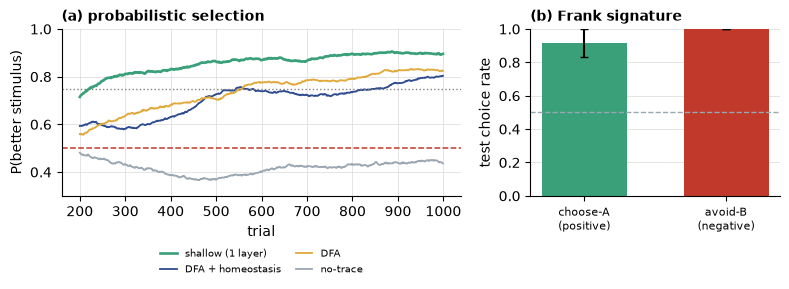

In [4]:
from mrl_trace.probselect import run_probselect, PST_CHANCE, PST_CRIT
from mrl_trace.stats import bootstrap_ci

if RUN_PROFILE == "smoke":
    PST_SEEDS, PST_TRIALS = 1, 250
elif RUN_PROFILE == "reduced":
    PST_SEEDS, PST_TRIALS = 6, 1000
else:
    PST_SEEDS, PST_TRIALS = 20, 5000

CONDS = ["shallow", "dfa_homeo", "dfa", "no_trace"]
job = partial(run_probselect, trials=PST_TRIALS, seeds=PST_SEEDS)
if N_WORKERS > 1:
    with ProcessPoolExecutor(max_workers=min(N_WORKERS, len(CONDS)),
                             mp_context=get_context("spawn")) as pool:
        results = list(pool.map(job, CONDS))
    PARALLEL_STATUS = f"spawn pool ({min(N_WORKERS, len(CONDS))} workers)"
else:
    results = [job(c) for c in CONDS]
    PARALLEL_STATUS = "serial (WORKERS=1)"

pst = {r["cond"]: r for r in results}
curves = {c: pst[c]["curve"] for c in CONDS}
finals = {c: pst[c]["finals"] for c in CONDS}
tests = {c: (pst[c]["chooseA"], pst[c]["avoidB"])
         for c in CONDS if pst[c]["chooseA"] is not None}
ci = {c: bootstrap_ci(finals[c]) for c in CONDS}
print({"seeds": PST_SEEDS, "trials": PST_TRIALS, "execution": PARALLEL_STATUS,
       "final_means": {c: round(float(finals[c].mean()), 3) for c in CONDS}})

COL = {"shallow": "#3aa07a", "dfa": "#e0a93b", "dfa_homeo": "#2f4b8f",
       "no_trace": "#9aa6b2"}
LABEL = {"shallow": "shallow (1 layer)", "dfa": "DFA",
         "dfa_homeo": "DFA + homeostasis", "no_trace": "no-trace"}
CHANCE, CRIT = PST_CHANCE, PST_CRIT

fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.0, 3.2),
                               gridspec_kw={"width_ratios": [1.6, 1.0]})
for c in ["shallow", "dfa_homeo", "dfa", "no_trace"]:
    tt = np.arange(200, 200 + len(curves[c]))
    axA.plot(tt, curves[c], color=COL[c], lw=1.9 if c == "shallow" else 1.3,
             label=LABEL[c])
axA.axhline(CHANCE, ls="--", color="#c0392b", lw=1.1)
axA.axhline(CRIT, ls=":", color="0.5", lw=1.0)
axA.set_xlabel("trial"); axA.set_ylabel("P(better stimulus)")
axA.set_ylim(0.3, 1.0)
axA.set_title("(a) probabilistic selection", loc="left", fontsize=10, fontweight="bold")
axA.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper center",
           bbox_to_anchor=(0.5, -0.26), columnspacing=1.4, handlelength=1.6)
axA.spines[["top", "right"]].set_visible(False)
axA.grid(True, which="major", color="0.85", lw=0.5, zorder=0)
axA.set_axisbelow(True)

cA, aB = tests["shallow"]
m = [cA.mean(), aB.mean()]
lo = [cA.mean() - bootstrap_ci(cA)[0], aB.mean() - bootstrap_ci(aB)[0]]
hi = [bootstrap_ci(cA)[1] - cA.mean(), bootstrap_ci(aB)[1] - aB.mean()]
axB.bar([0, 1], m, color=["#3aa07a", "#c0392b"], width=0.6,
        yerr=[lo, hi], capsize=3)
axB.axhline(0.5, ls="--", color="#9aa6b2", lw=1.0)
axB.set_xticks([0, 1]); axB.set_xticklabels(["choose-A\n(positive)", "avoid-B\n(negative)"],
                                            fontsize=8)
axB.set_ylabel("test choice rate"); axB.set_ylim(0, 1.0)
axB.set_title("(b) Frank signature", loc="left", fontsize=10, fontweight="bold")
axB.spines[["top", "right"]].set_visible(False)
axB.grid(True, axis="y", which="major", color="0.85", lw=0.5, zorder=0)
axB.set_axisbelow(True)
fig.tight_layout()

pst_hash = hash_arrays(*(curves[c] for c in CONDS), cA, aB)
finish(fig, "fig_probselect.png", "live-exact" if RUN_PROFILE == "publication" else "live-reduced",
       seeds=PST_SEEDS, data_hash=pst_hash)


## Measured dopamine signal

Requires analysis-ready DANDI 000351 session caches. When enabled, the cell runs the
authored outcome epoching and out-of-fold decoder before drawing the recorded two-panel
validation figure.


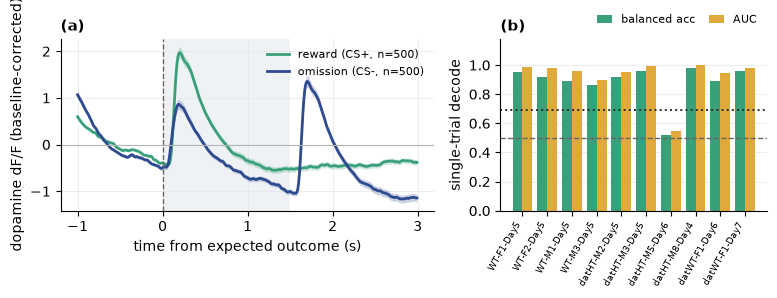

In [5]:
DA_FILES = [DA_ANALYSIS_CACHE / (Path(source["name"]).stem + ".npy")
            for source in DANDI_REDUCED_ASSETS
            if (DA_ANALYSIS_CACHE / (Path(source["name"]).stem + ".npy")).exists()]
if not RUN_EXTERNAL_DATA or not DA_FILES:
    external_gate(
        "fig_dopamine_signal.png", "DANDI 000351 dLight1.3b photometry",
        DA_ANALYSIS_CACHE,
        "Prepare per-session `.npy` files containing `dff`, `dff_t`, `sound_t`, "
        "`reward_t`, `fs`, and `sub`, then set `DA_CACHE` to that directory."
    )
else:
    from mrl_trace.dopamine import load_session, epoch_outcome, rewp_features, decode_reward

    allR, allO, baccs, aucs, names = [], [], [], [], []
    tref = None
    for fn in DA_FILES:
        sess = load_session(fn)
        ep, t, val = epoch_outcome(sess)
        if len(np.unique(val)) < 2 or len(val) < 40:
            continue
        tref = t
        allR.append(ep[val == 1]); allO.append(ep[val == 0])
        r = decode_reward(rewp_features(ep, t), val, seed=0)
        baccs.append(r["bal_acc"]); aucs.append(r["auc"])
        names.append(str(sess["sub"]).replace("sub-HJ-FP-", "").replace("-stGtACR", ""))
    if not allR or not allO:
        external_gate("fig_dopamine_signal.png", "DANDI 000351 dLight1.3b photometry",
                      DA_ANALYSIS_CACHE, "The cache exists but contains no session with both outcomes and at least 40 trials.")
    else:
        R = np.concatenate(allR); O = np.concatenate(allO)
        DA = "#3aa07a"; OM = "#2f4b8f"
        fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.0, 3.1),
                                       gridspec_kw={"width_ratios": [1.4, 1.0]})
        def msem(A):
            return A.mean(0), A.std(0) / np.sqrt(len(A))
        mR, sR = msem(R); mO, sO = msem(O)
        axA.axvspan(0, 1.5, color="#eef1f4", alpha=0.9, lw=0, zorder=0)
        axA.plot(tref, mR, color=DA, lw=2.0, label=f"reward (CS+, n={len(R)})")
        axA.fill_between(tref, mR - sR, mR + sR, color=DA, alpha=0.25, lw=0)
        axA.plot(tref, mO, color=OM, lw=2.0, label=f"omission (CS-, n={len(O)})")
        axA.fill_between(tref, mO - sO, mO + sO, color=OM, alpha=0.25, lw=0)
        axA.axvline(0, ls="--", color="0.4", lw=1.0); axA.axhline(0, color="0.7", lw=0.8)
        axA.set_xlabel("time from expected outcome (s)")
        axA.set_ylabel("dopamine dF/F (baseline-corrected)")
        axA.set_title("(a)", loc="left", fontsize=11, fontweight="bold")
        axA.legend(frameon=False, fontsize=8, loc="upper right")
        axA.spines[["top", "right"]].set_visible(False)
        axA.grid(True, color="0.9", lw=0.5); axA.set_axisbelow(True)

        x = np.arange(len(baccs))
        axB.bar(x - 0.2, baccs, 0.4, color=DA, label="balanced acc")
        axB.bar(x + 0.2, aucs, 0.4, color="#e0a93b", label="AUC")
        axB.axhline(0.69, ls=":", color="#2b2b2b", lw=1.4)
        axB.axhline(0.5, ls="--", color="0.4", lw=1.0)
        axB.set_xticks(x); axB.set_xticklabels(names, rotation=60, fontsize=6.5, ha="right")
        axB.set_ylabel("single-trial decode"); axB.set_ylim(0, 1.18)
        axB.set_title("(b)", loc="left", fontsize=11, fontweight="bold")
        axB.legend(frameon=False, fontsize=8, loc="lower right", ncol=2,
                   bbox_to_anchor=(1.0, 1.02), columnspacing=1.2, handlelength=1.4)
        axB.spines[["top", "right"]].set_visible(False)
        axB.grid(True, axis="y", color="0.9", lw=0.5); axB.set_axisbelow(True)
        fig.tight_layout()
        finish(fig, "fig_dopamine_signal.png", "live-exact" if RUN_PROFILE == "publication" else "live-reduced", seeds=len(baccs),
               data_hash=hash_arrays(R, O, baccs, aucs))


## Dopamine

The learning grid runs only from reward pools decoded in the preceding genuine-recording
pipeline. An old result archive is not treated as live data.


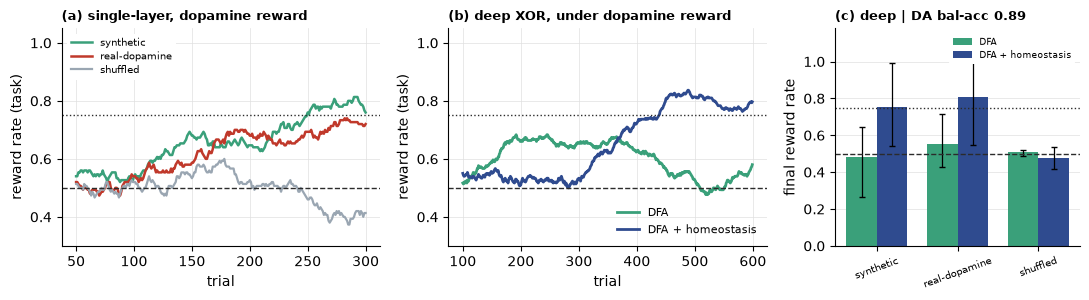

In [6]:
if not RUN_EXTERNAL_DATA or not DA_FILES or "R" not in globals():
    external_gate(
        "fig_dopamine_capstone.png", "DANDI 000351 decoded dopamine reward pools",
        DA_ANALYSIS_CACHE,
        "Prepare valid session caches as described above. This cell then recomputes both "
        "the shallow and deep learning grids; it does not load `exp11_dopamine_capstone.npy`."
    )
else:
    from mrl_trace.dopamine import (build_reward_pools as build_da_pools, make_shuffled_pools,
                                    run_dopamine_shallow, run_dopamine_deep)
    da_pools, da_meta = build_da_pools(str(DA_ANALYSIS_CACHE))
    if not len(da_pools[0]) or not len(da_pools[1]):
        external_gate("fig_dopamine_capstone.png", "DANDI 000351 decoded dopamine reward pools",
                      DA_ANALYSIS_CACHE, "No valid reward and omission pools were decoded.")
    else:
        if RUN_PROFILE == "smoke": da_seeds, da_ts, da_td = 1, 100, 200
        elif RUN_PROFILE == "reduced": da_seeds, da_ts, da_td = 3, 300, 600
        else: da_seeds, da_ts, da_td = 20, 600, 3000
        da_shuf = make_shuffled_pools(da_pools)
        da_shallow = run_dopamine_shallow(da_pools, da_shuf, seeds=da_seeds, trials=da_ts)
        if N_WORKERS > 1:
            with get_context("spawn").Pool(processes=min(N_WORKERS, 6)) as da_pool:
                da_deep = run_dopamine_deep(da_pools, da_shuf, seeds=da_seeds, trials=da_td, pool=da_pool)
        else:
            da_deep = run_dopamine_deep(da_pools, da_shuf, seeds=da_seeds, trials=da_td)

        SYN = "#3aa07a"; DA = "#c0392b"; SHUF = "#9aa6b2"; CR = "#2b2b2b"
        COL_RULE = {"dfa": "#3aa07a", "dfa_homeo": "#2f4b8f"}
        RULE_LABEL = {"dfa": "DFA", "dfa_homeo": "DFA + homeostasis"}
        REW = ["synthetic", "dopamine", "shuffled"]
        REW_LABEL = {"synthetic": "synthetic", "dopamine": "real-dopamine", "shuffled": "shuffled"}
        s_curves, s_finals, s_ci = da_shallow["curves"], da_shallow["finals"], da_shallow["ci"]
        d_curves, d_finals, d_ci = da_deep["curves"], da_deep["finals"], da_deep["ci"]
        fig, (axS, axD, axB) = plt.subplots(1, 3, figsize=(11.0, 3.1),
                                             gridspec_kw={"width_ratios": [1.3, 1.3, 1.0]})
        tt = np.arange(50, 50 + len(s_curves["synthetic"]))
        axS.plot(tt, s_curves["synthetic"], color=SYN, lw=1.8, label="synthetic")
        axS.plot(tt, s_curves["dopamine"], color=DA, lw=1.8, label="real-dopamine")
        axS.plot(tt, s_curves["shuffled"], color=SHUF, lw=1.6, label="shuffled")
        axS.axhline(0.5, ls="--", color=CR, lw=1.0); axS.axhline(0.75, ls=":", color=CR, lw=1.0)
        axS.set_xlabel("trial"); axS.set_ylabel("reward rate (task)"); axS.set_ylim(0.3, 1.05)
        axS.set_title("(a) single-layer, dopamine reward", loc="left", fontsize=9.5, fontweight="bold")
        axS.legend(fontsize=7.5, loc="upper left", framealpha=1.0, frameon=True,
                   facecolor="white", edgecolor="none", borderpad=0.4, labelspacing=0.3)
        axS.spines[["top", "right"]].set_visible(False); axS.grid(True, color="0.88", lw=0.5); axS.set_axisbelow(True)
        for rule in ("dfa", "dfa_homeo"):
            k = (rule, "dopamine"); tt = np.arange(100, 100 + len(d_curves[k]))
            axD.plot(tt, d_curves[k], color=COL_RULE[rule], lw=2.0, label=RULE_LABEL[rule])
        axD.axhline(0.5, ls="--", color=CR, lw=1.0); axD.axhline(0.75, ls=":", color=CR, lw=1.0)
        axD.set_xlabel("trial"); axD.set_ylabel("reward rate (task)"); axD.set_ylim(0.3, 1.05)
        axD.set_title("(b) deep XOR, under dopamine reward", loc="left", fontsize=9.5, fontweight="bold")
        axD.legend(frameon=False, fontsize=8, loc="lower right")
        axD.spines[["top", "right"]].set_visible(False); axD.grid(True, color="0.88", lw=0.5); axD.set_axisbelow(True)
        x = np.arange(len(REW)); w = 0.38
        for i, rule in enumerate(("dfa", "dfa_homeo")):
            m = [d_finals[(rule, r)].mean() for r in REW]
            lo = [m[j] - d_ci[(rule, REW[j])][0] for j in range(len(REW))]
            hi = [d_ci[(rule, REW[j])][1] - m[j] for j in range(len(REW))]
            axB.bar(x + (i - 0.5) * w, m, w, color=COL_RULE[rule], label=RULE_LABEL[rule],
                    yerr=[lo, hi], capsize=2.5, error_kw=dict(lw=0.9))
        axB.axhline(0.5, ls="--", color=CR, lw=1.0); axB.axhline(0.75, ls=":", color=CR, lw=1.0)
        axB.set_xticks(x); axB.set_xticklabels([REW_LABEL[r] for r in REW], fontsize=7.5, rotation=20)
        axB.set_ylabel("final reward rate"); axB.set_ylim(0, 1.18)
        axB.set_title(f"(c) deep | DA bal-acc {da_meta['mean_bal_acc']:.2f}", loc="left", fontsize=9.5, fontweight="bold")
        axB.legend(fontsize=6.8, loc="upper right", framealpha=1.0, frameon=True,
                   facecolor="white", edgecolor="none", borderpad=0.4, labelspacing=0.3)
        axB.spines[["top", "right"]].set_visible(False); axB.grid(True, axis="y", color="0.88", lw=0.5); axB.set_axisbelow(True)
        fig.tight_layout()
        finish(fig, "fig_dopamine_capstone.png", "live-exact" if RUN_PROFILE == "publication" else "live-reduced", seeds=da_seeds,
               data_hash=hash_arrays(*(s_curves.values()), *(d_curves.values())))


## EEG-gated Frank and combined reward figures

These cells require the OpenNeuro ds003474 EEGLAB/BIDS recording tree. The decoder uses
frontocentral feedback epochs and out-of-fold predictions. Both figures are generated
only after those predictions exist.


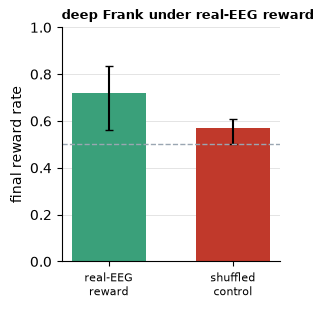

In [7]:
if RUN_EXTERNAL_DATA:
    from mrl_trace.biosignal import build_reward_pools as build_eeg_pools, run_biosignal_reward
    eeg_pools, eeg_meta = build_eeg_pools(str(EEG_DATA_DIR), cache=str(EEG_POOLS_CACHE))
else:
    eeg_pools, eeg_meta = {1: np.array([]), 0: np.array([])}, {}

EEG_AVAILABLE = bool(len(eeg_pools.get(1, [])) and len(eeg_pools.get(0, [])))
if not EEG_AVAILABLE:
    external_gate(
        "fig_probselect_eeg.png", "OpenNeuro ds003474 probabilistic-selection EEG",
        EEG_DATA_DIR,
        "Download the BIDS dataset with each subject's `_eeg.set`, `_eeg.fdt`, and "
        "`_events.tsv` files, set `SIOX_EEG_DIR`, and optionally set "
        "`SIOX_EEG_POOLS_CACHE` for the decoded out-of-fold reward pool."
    )
else:
    rng = np.random.default_rng(0)
    allv = np.concatenate([eeg_pools[1], eeg_pools[0]])
    eeg_shuf = {1: rng.permutation(allv), 0: rng.permutation(allv)}
    eeg_seeds = 1 if RUN_PROFILE == "smoke" else (3 if RUN_PROFILE == "reduced" else 20)
    eeg_trials = 250 if RUN_PROFILE == "smoke" else (1000 if RUN_PROFILE == "reduced" else 5000)
    eeg_conds = ["dfa_homeo_eeg", "dfa_homeo_shuf"]
    eeg_job = partial(run_probselect, trials=eeg_trials, seeds=eeg_seeds,
                      pools=eeg_pools, shuf=eeg_shuf)
    if N_WORKERS > 1:
        with ProcessPoolExecutor(max_workers=min(N_WORKERS, 2),
                                 mp_context=get_context("spawn")) as pool:
            eeg_jobs = list(pool.map(eeg_job, eeg_conds))
    else:
        eeg_jobs = [eeg_job(c) for c in eeg_conds]
    eeg_pst = {r["cond"]: r for r in eeg_jobs}
    eeg_finals = {k: v["finals"] for k, v in eeg_pst.items()}
    eeg_ci = {k: bootstrap_ci(v) for k, v in eeg_finals.items()}
    order = ["dfa_homeo_eeg", "dfa_homeo_shuf"]
    mc = [eeg_finals[c].mean() for c in order]
    loc_ = [mc[i] - eeg_ci[c][0] for i, c in enumerate(order)]
    hic_ = [eeg_ci[c][1] - mc[i] for i, c in enumerate(order)]
    fig, axC = plt.subplots(1, 1, figsize=(3.0, 3.2))
    axC.bar([0, 1], mc, color=["#3aa07a", "#c0392b"], width=0.6,
            yerr=[loc_, hic_], capsize=3)
    axC.axhline(0.5, ls="--", color="#9aa6b2", lw=1.0)
    axC.set_xticks([0, 1]); axC.set_xticklabels(["real-EEG\nreward", "shuffled\ncontrol"], fontsize=8)
    axC.set_ylabel("final reward rate"); axC.set_ylim(0, 1.0)
    axC.set_title("deep Frank under real-EEG reward", loc="left", fontsize=9.5, fontweight="bold")
    axC.spines[["top", "right"]].set_visible(False)
    axC.grid(True, axis="y", which="major", color="0.85", lw=0.5, zorder=0); axC.set_axisbelow(True)
    fig.tight_layout()
    finish(fig, "fig_probselect_eeg.png", "live-exact" if RUN_PROFILE == "publication" else "live-reduced", seeds=eeg_seeds,
           data_hash=hash_arrays(*(eeg_finals.values())))


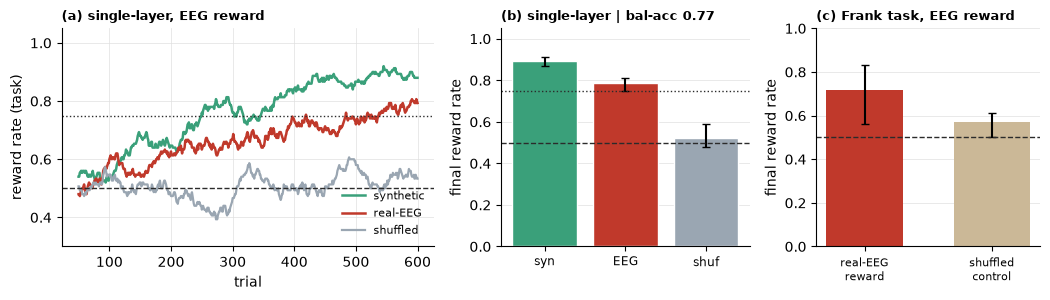

In [8]:
if not EEG_AVAILABLE:
    external_gate(
        "fig_eeg_combined.png", "OpenNeuro ds003474 probabilistic-selection EEG",
        EEG_DATA_DIR,
        "Prepare the same genuine EEG recording tree and decoded reward pools required "
        "by `fig_probselect_eeg.png`; this composite recomputes its single-layer learning arm."
    )
else:
    bio_trials = 150 if RUN_PROFILE == "smoke" else (600 if RUN_PROFILE == "reduced" else 600)
    bio_seeds = 1 if RUN_PROFILE == "smoke" else (3 if RUN_PROFILE == "reduced" else 20)
    bio = run_biosignal_reward(eeg_pools, eeg_meta, seeds=bio_seeds, trials=bio_trials)
    SYN = "#3aa07a"; EEG = "#c0392b"; SHUF = "#9aa6b2"; CR = "#2b2b2b"
    fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(10.6, 3.1),
                                        gridspec_kw={"width_ratios": [1.5, 1.0, 0.9]})
    cur = bio["curves"]
    tt = np.arange(50, 50 + len(cur["synthetic"]))
    axA.plot(tt, cur["synthetic"], color=SYN, lw=1.8, label="synthetic")
    axA.plot(tt, cur["biosignal"], color=EEG, lw=1.8, label="real-EEG")
    axA.plot(tt, cur["shuffled"], color=SHUF, lw=1.6, label="shuffled")
    axA.axhline(bio["chance"], ls="--", color=CR, lw=1.0); axA.axhline(bio["crit"], ls=":", color=CR, lw=1.0)
    axA.set_xlabel("trial"); axA.set_ylabel("reward rate (task)"); axA.set_ylim(0.3, 1.05)
    axA.set_title("(a) single-layer, EEG reward", loc="left", fontsize=9.5, fontweight="bold")
    axA.legend(frameon=False, fontsize=8, loc="lower right")
    axA.spines[["top", "right"]].set_visible(False); axA.grid(True, color="0.88", lw=0.5); axA.set_axisbelow(True)
    names = ["synthetic", "biosignal", "shuffled"]; cols = [SYN, EEG, SHUF]
    means = [bio["finals"][n].mean() for n in names]
    cis = [bootstrap_ci(bio["finals"][n]) for n in names]
    err = [[m - lo for m, (lo, hi) in zip(means, cis)], [hi - m for m, (lo, hi) in zip(means, cis)]]
    axB.bar(range(3), means, yerr=err, color=cols, capsize=3, edgecolor="white")
    axB.axhline(bio["crit"], ls=":", color=CR, lw=1.0); axB.axhline(bio["chance"], ls="--", color=CR, lw=1.0)
    axB.set_xticks(range(3)); axB.set_xticklabels(["syn", "EEG", "shuf"], fontsize=8.5)
    axB.set_ylabel("final reward rate"); axB.set_ylim(0, 1.05)
    axB.set_title(f"(b) single-layer | bal-acc {eeg_meta['mean_bal_acc']:.2f}", loc="left", fontsize=9.5, fontweight="bold")
    axB.spines[["top", "right"]].set_visible(False); axB.grid(True, axis="y", color="0.88", lw=0.5); axB.set_axisbelow(True)
    axC.bar([0, 1], mc, color=[EEG, "#cbb897"], width=0.6, yerr=[loc_, hic_], capsize=3)
    axC.axhline(bio["chance"], ls="--", color=CR, lw=1.0)
    axC.set_xticks([0, 1]); axC.set_xticklabels(["real-EEG\nreward", "shuffled\ncontrol"], fontsize=8)
    axC.set_ylabel("final reward rate"); axC.set_ylim(0, 1.0)
    axC.set_title("(c) Frank task, EEG reward", loc="left", fontsize=9.5, fontweight="bold")
    axC.spines[["top", "right"]].set_visible(False); axC.grid(True, axis="y", color="0.88", lw=0.5); axC.set_axisbelow(True)
    fig.tight_layout()
    finish(fig, "fig_eeg_combined.png", "live-exact" if RUN_PROFILE == "publication" else "live-reduced", seeds=bio_seeds,
           data_hash=hash_arrays(*(cur.values()), *(bio["finals"].values()), *(eeg_finals.values())))


## Notebook report

Each owned target appears exactly once in the report. Gated entries contain no rendered
image and cannot be saved as regenerated manuscript figures.


In [9]:
assert len(FIGURE_REPORT) == 5
assert len({r["filename"] for r in FIGURE_REPORT}) == 5
assert all(r["saved_path"] is None for r in FIGURE_REPORT) if not SAVE_FIGURES else True
FIGURE_REPORT


[{'filename': 'fig_probselect.png',
  'tier': 'supplementary',
  'notebook': '04_biological_grounding.ipynb',
  'profile': 'reduced',
  'device': 'cpu',
  'seeds': 6,
  'data_hash': None,
  'reference_hash': '88669092766af1307ca01e3a29fd541922f28f09db032f764399bdb13b4414f9',
  'provenance_class': 'live-reduced',
  'claim_status': 'reduced-validation',
  'runtime_profile': 'reduced',
  'runtime_device': 'cpu',
  'runtime_seeds': 6,
  'runtime_data_hash': '2539756dc192c6f69b4ffdeac565782c4a6e59b2a35b773642153bcd18344afb',
  'saved_path': None,
  'display_status': 'live-reduced'},
 {'filename': 'fig_dopamine_signal.png',
  'tier': 'supplementary',
  'notebook': '04_biological_grounding.ipynb',
  'profile': 'publication',
  'device': 'cpu',
  'seeds': None,
  'data_hash': None,
  'reference_hash': 'f30368535aa82149582011b344494e5ed6fef1023b1e94c3ac6a3794eaddd0d5',
  'provenance_class': 'live-reduced',
  'claim_status': 'reduced-validation',
  'runtime_profile': 'reduced',
  'runtime_device